In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the data
data = pd.read_excel('data1319.xlsx', sheet_name='Sheet1')

/Users/charlesyamamura/ls/envs/aienv/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [8]:
print(data.head())

   year  mo     model  novelty  brand  style  rugged  space  trunk  comfort  \
0  2013   1       ASX        5      5      4       4      3      3        4   
1  2013   1    Duster        5      3      1       4      4      4        3   
2  2013   1  Ecosport        5      3      2       2      2      2        2   
3  2013   1      IX35        5      5      3       3      3      5        4   
4  2013   1  Sportage        5      4      4       4      3      4        4   

   nimble  versatile  finish  features  infotain  perform  economy  safety  \
0       3          3       4         3         3        3        2       4   
1       3          4       1         2         2        3        2       2   
2       4          3       2         3         2        3        3       3   
3       3          4       3         3         3        3        2       3   
4       3          4       4         3         4        3        2       4   

   price     share  
0      3  0.206837  
1      4  1.24

In [3]:
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 944 entries, 0 to 943
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   year       944 non-null    int64  
 1   mo         944 non-null    int64  
 2   model      944 non-null    str    
 3   novelty    944 non-null    int64  
 4   brand      944 non-null    int64  
 5   style      944 non-null    int64  
 6   rugged     944 non-null    int64  
 7   space      944 non-null    int64  
 8   trunk      944 non-null    int64  
 9   comfort    944 non-null    int64  
 10  nimble     944 non-null    int64  
 11  versatile  944 non-null    int64  
 12  finish     944 non-null    int64  
 13  features   944 non-null    int64  
 14  infotain   944 non-null    int64  
 15  perform    944 non-null    int64  
 16  economy    944 non-null    int64  
 17  safety     944 non-null    int64  
 18  price      944 non-null    int64  
 19  share      944 non-null    float64
dtypes: float64(1), int64(

In [9]:
print(data.tail())

     year  mo    model  novelty  brand  style  rugged  space  trunk  comfort  \
939  2019   9  Tiggo5X        5      3      3       2      3      1        3   
940  2019   9   Tiggo7        5      3      4       2      4      4        4   
941  2019   9  Tracker        3      4      3       3      3      2        3   
942  2019   9   Tucson        4      5      4       3      4      5        4   
943  2019   9      WRV        4      5      2       2      3      4        2   

     nimble  versatile  finish  features  infotain  perform  economy  safety  \
939       3          4       3         4         3        4        3       3   
940       3          3       3         4         3        3        3       3   
941       4          4       2         3         4        4        3       3   
942       3          4       3         3         4        5        4       4   
943       4          5       3         2         3        1        5       3   

     price     share  
939      3  0.3

In [4]:
# Basic Statistics
print(data.describe())

              year          mo     novelty       brand       style  \
count   944.000000  944.000000  944.000000  944.000000  944.000000   
mean   2016.636653    6.363347    3.795551    4.098517    2.971398   
std       1.867956    3.347713    1.266060    0.990858    1.068307   
min    2013.000000    1.000000    1.000000    2.000000    1.000000   
25%    2015.000000    4.000000    3.000000    3.000000    2.000000   
50%    2017.000000    6.000000    4.000000    4.000000    3.000000   
75%    2018.000000    9.000000    5.000000    5.000000    4.000000   
max    2019.000000   12.000000    5.000000    5.000000    4.000000   

           rugged       space       trunk     comfort      nimble   versatile  \
count  944.000000  944.000000  944.000000  944.000000  944.000000  944.000000   
mean     3.182203    3.181144    3.389831    3.168432    3.309322    3.721398   
std      0.765550    0.738305    1.224763    0.695554    0.532783    0.619348   
min      2.000000    2.000000    1.000000    

In [5]:
# Check for missing values
print(data.isnull().sum())

year         0
mo           0
model        0
novelty      0
brand        0
style        0
rugged       0
space        0
trunk        0
comfort      0
nimble       0
versatile    0
finish       0
features     0
infotain     0
perform      0
economy      0
safety       0
price        0
share        0
dtype: int64


In [ ]:
# Frequency of each model
print(data['model'].value_counts())

model
ASX         81
Duster      81
Ecosport    81
Sportage    81
Tucson      81
IX35        80
Tracker     72
HRV         55
P2008       53
Renegade    53
Kicks       39
Captur      33
Compass     33
Creta       33
WRV         31
Tiggo       17
Cactus      13
Eclipse     10
Tiggo5X      8
Tcross       6
Tiggo7       3
Name: count, dtype: int64


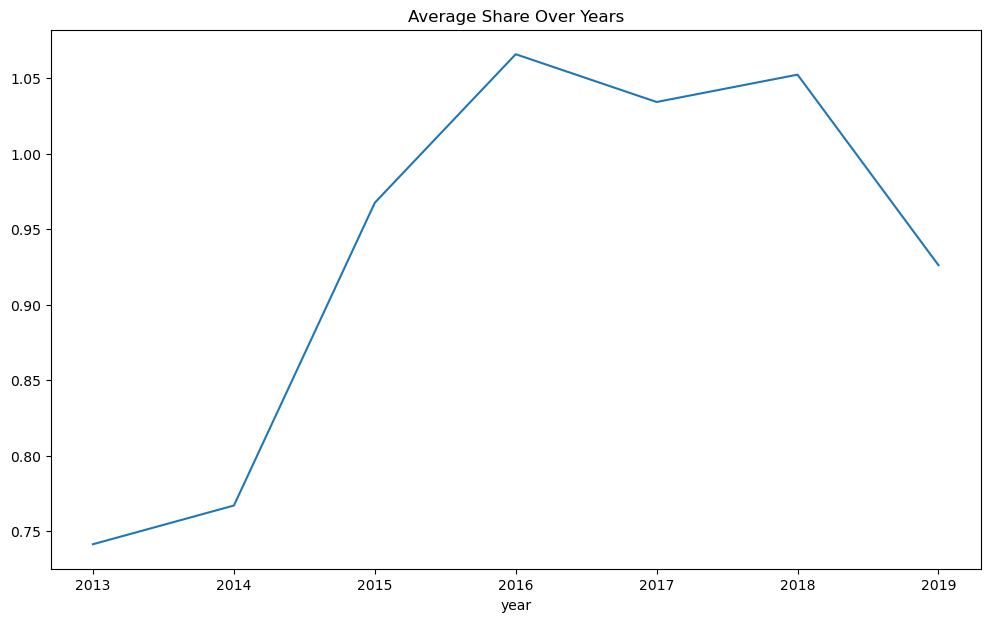

In [24]:
# Yearly Trends
plt.figure(figsize=(12,7))
yearly_share = data.groupby('year')['share'].mean()
yearly_share.plot(kind='line', title='Average Share Over Years')
plt.show()

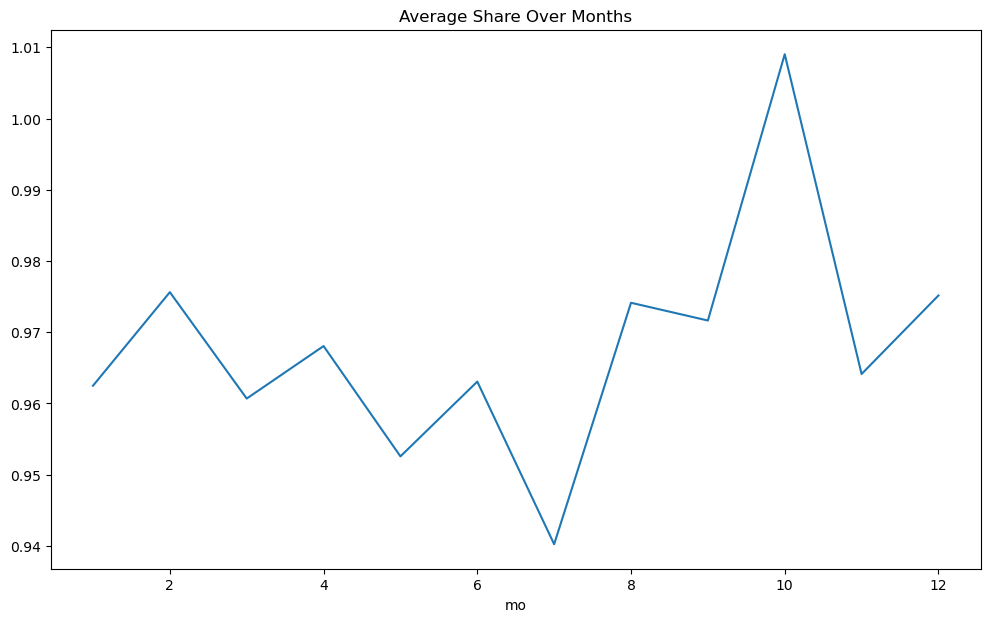

In [23]:
# Monthly Trends
plt.figure(figsize=(12,7))
monthly_share = data.groupby('mo')['share'].mean()
monthly_share.plot(kind='line', title='Average Share Over Months')
plt.show()

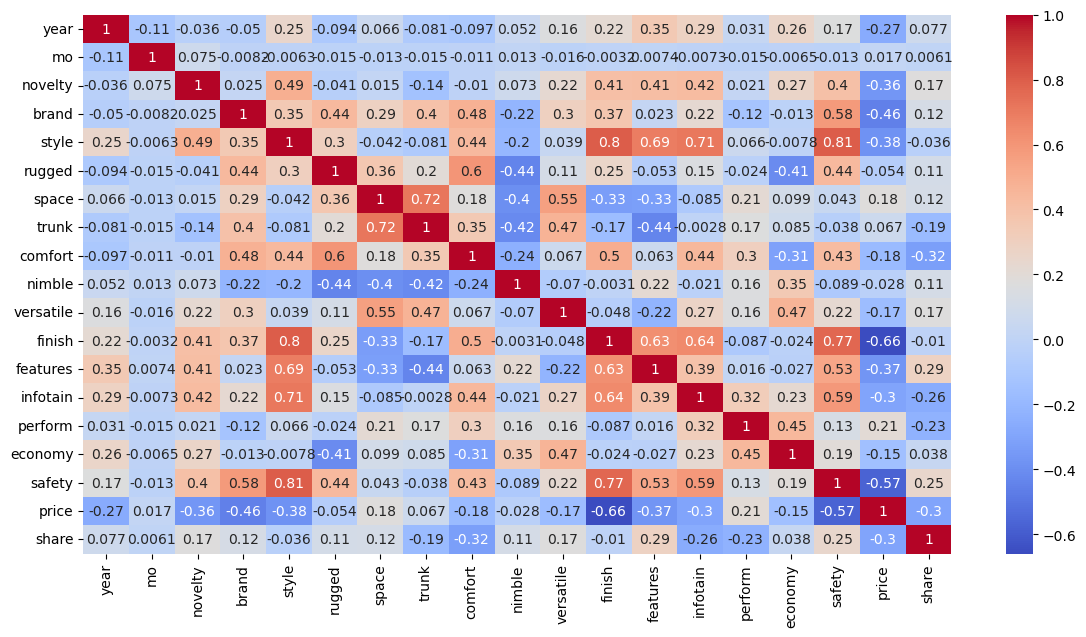

In [14]:
# Correlation Matrix (only numeric columns)
numeric_data = data.select_dtypes(include=['float64', 'int64'])
corr_matrix = numeric_data.corr()
plt.figure(figsize=(14, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

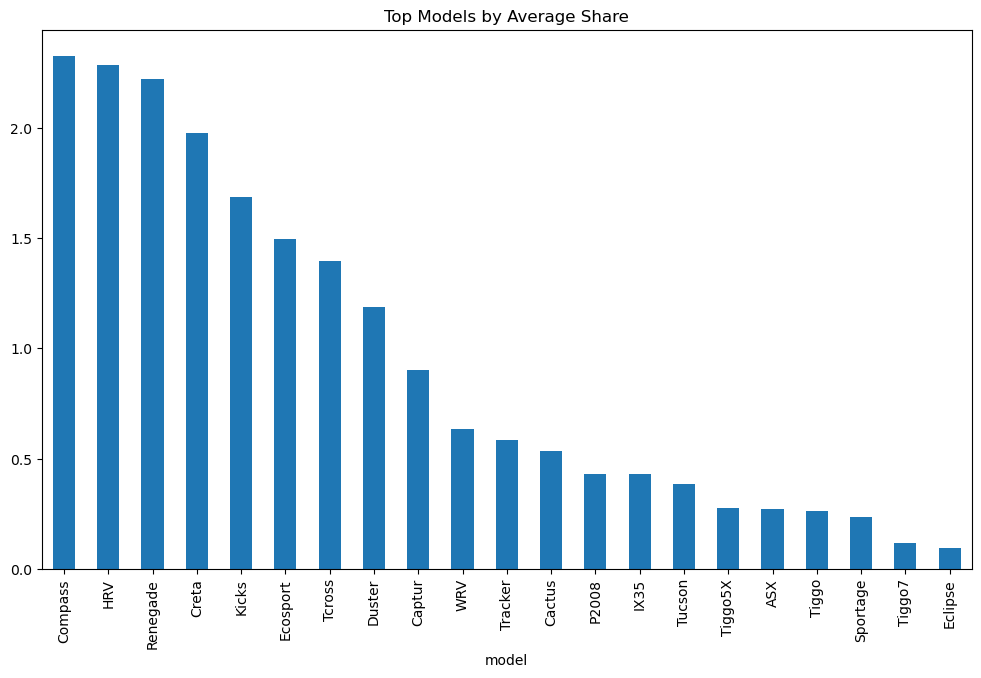

In [22]:
# Top Models by Average Share
plt.figure(figsize=(12,7))
top_models = data.groupby('model')['share'].mean().sort_values(ascending=False)
top_models.plot(kind='bar', title='Top Models by Average Share')
plt.show()

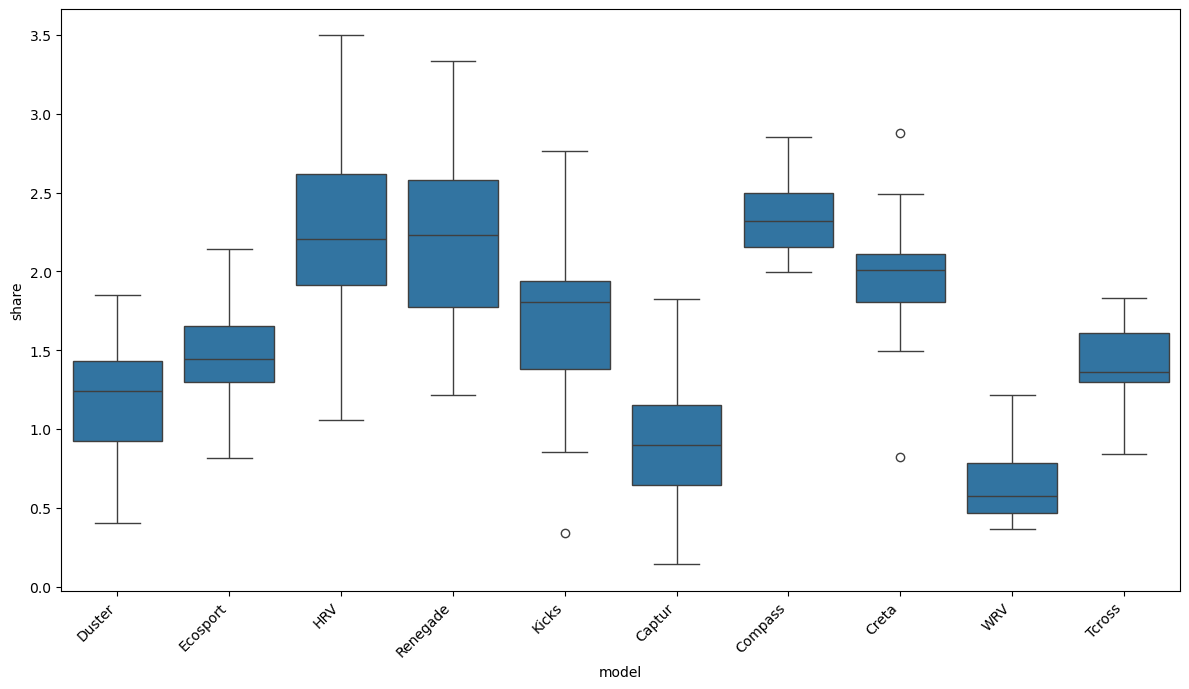

In [ ]:
# Attribute Comparison for Top Models
top_models_list = top_models.index[:10]
top_models_data = data[data['model'].isin(top_models_list)]
plt.figure(figsize=(12, 7))   # <-- create figure FIRST
sns.boxplot(x='model', y='share', data=top_models_data)
plt.xticks(rotation=45, ha='right')  # optional, if many models
plt.tight_layout()
plt.show()

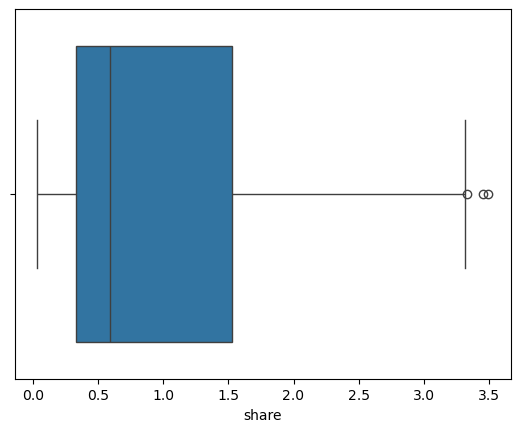

In [21]:
# Outlier Detection
sns.boxplot(x=data['share'])
plt.show()